# Position Compositions per Match — Can We Canonically Order Players for gMLP?

**Goal:** Understand if players within a match can be sorted into a fixed canonical order based on `position_id`, so that the static spatial projection matrix W in gMLP can learn meaningful cross-token patterns.

**Key questions:**
1. How many players per team per match? (always 11? subs?)
2. What is the distribution of position_id values?
3. How many unique "position compositions" (multisets of positions) exist per team?
4. Are there duplicate positions within a team? (e.g., 2 center backs)
5. Can we define a canonical ordering: sort by position_id, then break ties deterministically?

In [1]:
import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../../dataset/data_with_dates.csv")
print(f"Total rows: {len(df)}")
print(f"Unique matches: {df['match_id'].nunique()}")
print(f"Unique players: {df['player_name'].nunique()}")
print(f"Columns: {list(df.columns[:10])}")
df.head(3)

Total rows: 64306
Unique matches: 2923
Unique players: 6393
Columns: ['player_name', 'team_name', 'competition_name', 'season_name', 'match_id', 'match_date', 'is_aligned', 'position_id', 'position_name', 'pass_total']


,player_name,team_name,competition_name,season_name,match_id,match_date,is_aligned,position_id,position_name,pass_total,...,foul_won_total,foul_won_penalty,foul_committed_total,foul_committed_penalty,foul_committed_yellow_card,foul_committed_red_card,goalkeeper_goal_conceded,goalkeeper_save,goalkeeper_shot_faced,counterpress_total
0,Lukáš Hrádecký,Bayer Leverkusen,1. Bundesliga,2023/2024,3895302,2024-04-14,1,1,Goalkeeper,24,...,0,0,0,0,0,0,0,0,0,0
1,Odilon Kossonou,Bayer Leverkusen,1. Bundesliga,2023/2024,3895302,2024-04-14,1,3,Right Center Back,77,...,0,0,1,0,0,0,0,0,0,0
2,Jonathan Tah,Bayer Leverkusen,1. Bundesliga,2023/2024,3895302,2024-04-14,1,4,Center Back,74,...,0,0,1,0,0,0,0,0,0,0


## 1. Position vocabulary — StatsBomb 25 positions

In [2]:
# All unique positions and their frequencies
pos_counts = df.groupby(["position_id", "position_name"]).size().reset_index(name="count")
pos_counts = pos_counts.sort_values("position_id")
print(f"Unique position_id values: {sorted(df['position_id'].unique())}")
print(f"Number of unique positions: {df['position_id'].nunique()}\n")
pos_counts

Unique position_id values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25)]
Number of unique positions: 25



,position_id,position_name,count
0,1,Goalkeeper,5846
1,2,Right Back,5044
2,3,Right Center Back,5845
3,4,Center Back,803
4,5,Left Center Back,5846
5,6,Left Back,5042
6,7,Right Wing Back,790
7,8,Left Wing Back,789
8,9,Right Defensive Midfield,2929
9,10,Center Defensive Midfield,2428


## 2. How many players per team per match?

Players per team per match — distribution:
count    5846.0
mean       11.0
std         0.0
min        11.0
25%        11.0
50%        11.0
75%        11.0
max        11.0
Name: n_players, dtype: float64

Value counts:
n_players
11    5846
Name: count, dtype: int64


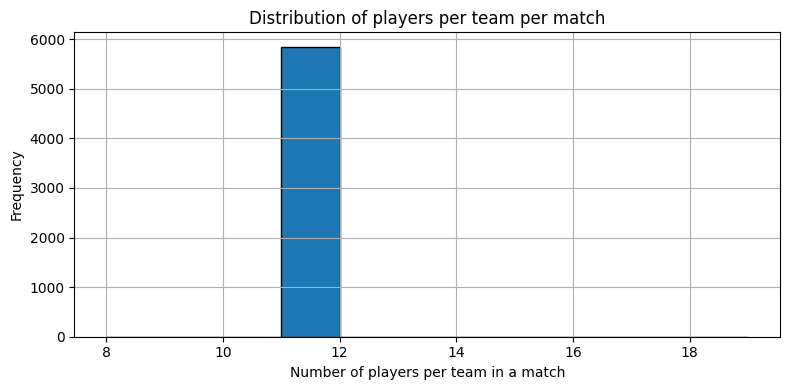

In [3]:
# Players per team per match
team_match_counts = df.groupby(["match_id", "team_name"]).size().reset_index(name="n_players")

print("Players per team per match — distribution:")
print(team_match_counts["n_players"].describe())
print(f"\nValue counts:")
print(team_match_counts["n_players"].value_counts().sort_index())

fig, ax = plt.subplots(figsize=(8, 4))
team_match_counts["n_players"].hist(bins=range(8, 20), ax=ax, edgecolor="black")
ax.set_xlabel("Number of players per team in a match")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of players per team per match")
plt.tight_layout()
plt.show()

In [4]:
# Total players per match (both teams)
match_counts = df.groupby("match_id").size().reset_index(name="n_players")
print("Total players per match (both teams):")
print(match_counts["n_players"].describe())
print(f"\nValue counts:")
print(match_counts["n_players"].value_counts().sort_index())

Total players per match (both teams):
count    2923.0
mean       22.0
std         0.0
min        22.0
25%        22.0
50%        22.0
75%        22.0
max        22.0
Name: n_players, dtype: float64

Value counts:
n_players
22    2923
Name: count, dtype: int64


## 3. Duplicate positions within a team — how often does a team have 2+ players with the same position_id?

In [5]:
# For each (match, team), count how many players share the same position_id
pos_dupes = df.groupby(["match_id", "team_name", "position_id"]).size().reset_index(name="count")
pos_dupes_gt1 = pos_dupes[pos_dupes["count"] > 1]

total_team_matches = df.groupby(["match_id", "team_name"]).ngroups
teams_with_dupes = pos_dupes_gt1.groupby(["match_id", "team_name"]).ngroups

print(f"Total (match, team) pairs: {total_team_matches}")
print(f"Pairs with at least one duplicate position_id: {teams_with_dupes} ({100*teams_with_dupes/total_team_matches:.1f}%)")
print(f"\nDistribution of duplicate counts (how many players share same position within a team):")
print(pos_dupes_gt1["count"].value_counts().sort_index())

# Which positions are most often duplicated?
print(f"\nMost duplicated positions:")
dupe_pos = pos_dupes_gt1.merge(
    df[["position_id", "position_name"]].drop_duplicates(), on="position_id"
)
print(dupe_pos.groupby(["position_id", "position_name"]).size().sort_values(ascending=False).head(15))

Total (match, team) pairs: 5846
Pairs with at least one duplicate position_id: 0 (0.0%)

Distribution of duplicate counts (how many players share same position within a team):
Series([], Name: count, dtype: int64)

Most duplicated positions:
Series([], dtype: int64)


## 4. Unique position compositions per team (multiset of position_ids)

How many distinct "tactical formations" (as multisets of positions) exist?

In [6]:
# Build a "composition signature" for each (match, team):
# tuple of sorted position_ids
def get_composition(group):
    return tuple(sorted(group["position_id"].values))

compositions = df.groupby(["match_id", "team_name"]).apply(get_composition).reset_index(name="composition")
compositions["n_players"] = compositions["composition"].apply(len)

print(f"Total (match, team) entries: {len(compositions)}")
print(f"Unique position compositions (multisets): {compositions['composition'].nunique()}")

# Top 20 most common compositions
comp_counts = compositions["composition"].value_counts()
print(f"\nTop 20 most common compositions:")
for i, (comp, count) in enumerate(comp_counts.head(20).items()):
    pct = 100 * count / len(compositions)
    print(f"  {i+1:2d}. {comp} — {count} times ({pct:.1f}%), {len(comp)} players")

Total (match, team) entries: 5846
Unique position compositions (multisets): 57

Top 20 most common compositions:
   1. (np.int64(1), np.int64(2), np.int64(3), np.int64(5), np.int64(6), np.int64(9), np.int64(11), np.int64(17), np.int64(19), np.int64(21), np.int64(23)) — 1480 times (25.3%), 11 players
   2. (np.int64(1), np.int64(2), np.int64(3), np.int64(5), np.int64(6), np.int64(10), np.int64(13), np.int64(15), np.int64(17), np.int64(21), np.int64(23)) — 1333 times (22.8%), 11 players
   3. (np.int64(1), np.int64(2), np.int64(3), np.int64(5), np.int64(6), np.int64(9), np.int64(11), np.int64(12), np.int64(16), np.int64(22), np.int64(24)) — 823 times (14.1%), 11 players
   4. (np.int64(1), np.int64(2), np.int64(3), np.int64(5), np.int64(6), np.int64(10), np.int64(12), np.int64(13), np.int64(15), np.int64(16), np.int64(23)) — 396 times (6.8%), 11 players
   5. (np.int64(1), np.int64(2), np.int64(3), np.int64(5), np.int64(6), np.int64(10), np.int64(13), np.int64(15), np.int64(19), np.int64

In [7]:
# What % of data is covered by top-N compositions?
cumsum = comp_counts.cumsum()
total = len(compositions)
for n in [5, 10, 20, 50, 100]:
    if n <= len(cumsum):
        pct = 100 * cumsum.iloc[n-1] / total
        print(f"Top {n:3d} compositions cover {pct:.1f}% of all (match, team) entries")

print(f"\nTotal unique compositions: {len(comp_counts)}")

Top   5 compositions cover 74.4% of all (match, team) entries
Top  10 compositions cover 91.8% of all (match, team) entries
Top  20 compositions cover 99.0% of all (match, team) entries
Top  50 compositions cover 99.9% of all (match, team) entries

Total unique compositions: 57


## 5. Only 11-player lineups (starting XI)

The dataset likely includes substitutes. Let's filter to exactly 11 players per team and re-check compositions.

In [8]:
# Filter compositions with exactly 11 players
comp_11 = compositions[compositions["n_players"] == 11]
print(f"(match, team) with exactly 11 players: {len(comp_11)} / {len(compositions)} ({100*len(comp_11)/len(compositions):.1f}%)")
print(f"Unique 11-player compositions: {comp_11['composition'].nunique()}")

comp_11_counts = comp_11["composition"].value_counts()
print(f"\nTop 20 most common 11-player compositions:")
for i, (comp, count) in enumerate(comp_11_counts.head(20).items()):
    pct = 100 * count / len(comp_11)
    print(f"  {i+1:2d}. {comp} — {count} times ({pct:.1f}%)")

# Coverage
cumsum_11 = comp_11_counts.cumsum()
total_11 = len(comp_11)
print()
for n in [5, 10, 20, 50, 100]:
    if n <= len(cumsum_11):
        pct = 100 * cumsum_11.iloc[n-1] / total_11
        print(f"Top {n:3d} compositions cover {pct:.1f}% of 11-player entries")

(match, team) with exactly 11 players: 5846 / 5846 (100.0%)
Unique 11-player compositions: 57

Top 20 most common 11-player compositions:
   1. (np.int64(1), np.int64(2), np.int64(3), np.int64(5), np.int64(6), np.int64(9), np.int64(11), np.int64(17), np.int64(19), np.int64(21), np.int64(23)) — 1480 times (25.3%)
   2. (np.int64(1), np.int64(2), np.int64(3), np.int64(5), np.int64(6), np.int64(10), np.int64(13), np.int64(15), np.int64(17), np.int64(21), np.int64(23)) — 1333 times (22.8%)
   3. (np.int64(1), np.int64(2), np.int64(3), np.int64(5), np.int64(6), np.int64(9), np.int64(11), np.int64(12), np.int64(16), np.int64(22), np.int64(24)) — 823 times (14.1%)
   4. (np.int64(1), np.int64(2), np.int64(3), np.int64(5), np.int64(6), np.int64(10), np.int64(12), np.int64(13), np.int64(15), np.int64(16), np.int64(23)) — 396 times (6.8%)
   5. (np.int64(1), np.int64(2), np.int64(3), np.int64(5), np.int64(6), np.int64(10), np.int64(13), np.int64(15), np.int64(19), np.int64(22), np.int64(24)) — 3

## 6. Canonical ordering analysis

If we sort players by `position_id` within each team, how many "slots" have a unique position vs ambiguous (shared) position?

Per team per match — players with ambiguous (duplicate) position:
count    5846.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: n_ambiguous, dtype: float64

Teams with 0 ambiguous players: 5846 / 5846 (100.0%)


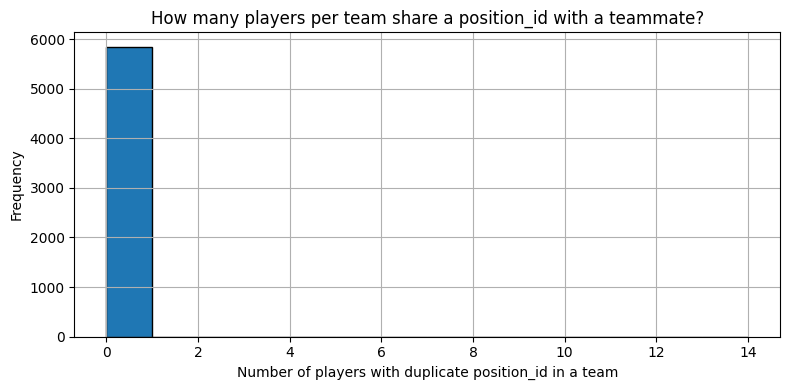

In [9]:
# For each (match, team): how many positions appear more than once?
# = how many players would have ambiguous ordering

def count_ambiguous_slots(group):
    pos_counts = Counter(group["position_id"].values)
    n_ambiguous = sum(c for c in pos_counts.values() if c > 1)  # total players in duplicated positions
    n_unique = sum(1 for c in pos_counts.values() if c == 1)    # players with unique position
    return pd.Series({"n_ambiguous": n_ambiguous, "n_unique": n_unique, "n_total": len(group)})

ambig = df.groupby(["match_id", "team_name"]).apply(count_ambiguous_slots).reset_index()

print("Per team per match — players with ambiguous (duplicate) position:")
print(ambig["n_ambiguous"].describe())
print(f"\nTeams with 0 ambiguous players: {(ambig['n_ambiguous'] == 0).sum()} / {len(ambig)} ({100*(ambig['n_ambiguous'] == 0).mean():.1f}%)")

fig, ax = plt.subplots(figsize=(8, 4))
ambig["n_ambiguous"].hist(bins=range(0, 15), ax=ax, edgecolor="black")
ax.set_xlabel("Number of players with duplicate position_id in a team")
ax.set_ylabel("Frequency")
ax.set_title("How many players per team share a position_id with a teammate?")
plt.tight_layout()
plt.show()

## 7. Proposed canonical ordering: sort by position_id, break ties by player_name

Let's see what the resulting sequences look like and how stable the slot assignments are.

In [10]:
# Show a few example matches with canonical ordering
sample_matches = df["match_id"].unique()[:3]

for mid in sample_matches:
    match_df = df[df["match_id"] == mid]
    teams = sorted(match_df["team_name"].unique())
    print(f"=== Match {mid} ===")
    for team in teams:
        team_df = match_df[match_df["team_name"] == team].sort_values(
            ["position_id", "player_name"]
        )
        print(f"\n  Team: {team} ({len(team_df)} players)")
        for slot_idx, (_, row) in enumerate(team_df.iterrows()):
            print(f"    Slot {slot_idx:2d}: pos_id={int(row['position_id']):2d} ({row['position_name']:30s}) — {row['player_name']}")
    print()

=== Match 3895302 ===

  Team: Bayer Leverkusen (11 players)
    Slot  0: pos_id= 1 (Goalkeeper                    ) — Lukáš Hrádecký
    Slot  1: pos_id= 3 (Right Center Back             ) — Odilon Kossonou
    Slot  2: pos_id= 4 (Center Back                   ) — Jonathan Tah
    Slot  3: pos_id= 5 (Left Center Back              ) — Edmond Fayçal Tapsoba
    Slot  4: pos_id= 7 (Right Wing Back               ) — Nathan Tella
    Slot  5: pos_id= 8 (Left Wing Back                ) — Piero Martín Hincapié Reyna
    Slot  6: pos_id= 9 (Right Defensive Midfield      ) — Granit Xhaka
    Slot  7: pos_id=11 (Left Defensive Midfield       ) — Robert Andrich
    Slot  8: pos_id=18 (Right Attacking Midfield      ) — Jonas Hofmann
    Slot  9: pos_id=20 (Left Attacking Midfield       ) — Amine Adli
    Slot 10: pos_id=23 (Center Forward                ) — Victor Okoh Boniface

  Team: Werder Bremen (11 players)
    Slot  0: pos_id= 1 (Goalkeeper                    ) — Michael Zetterer
    Slot 

## 8. Slot stability: how consistent is each slot's position_id across matches?

If slot 0 is always GK, slot 1 is always RB, etc. — the ordering is stable and gMLP can learn meaningful W.

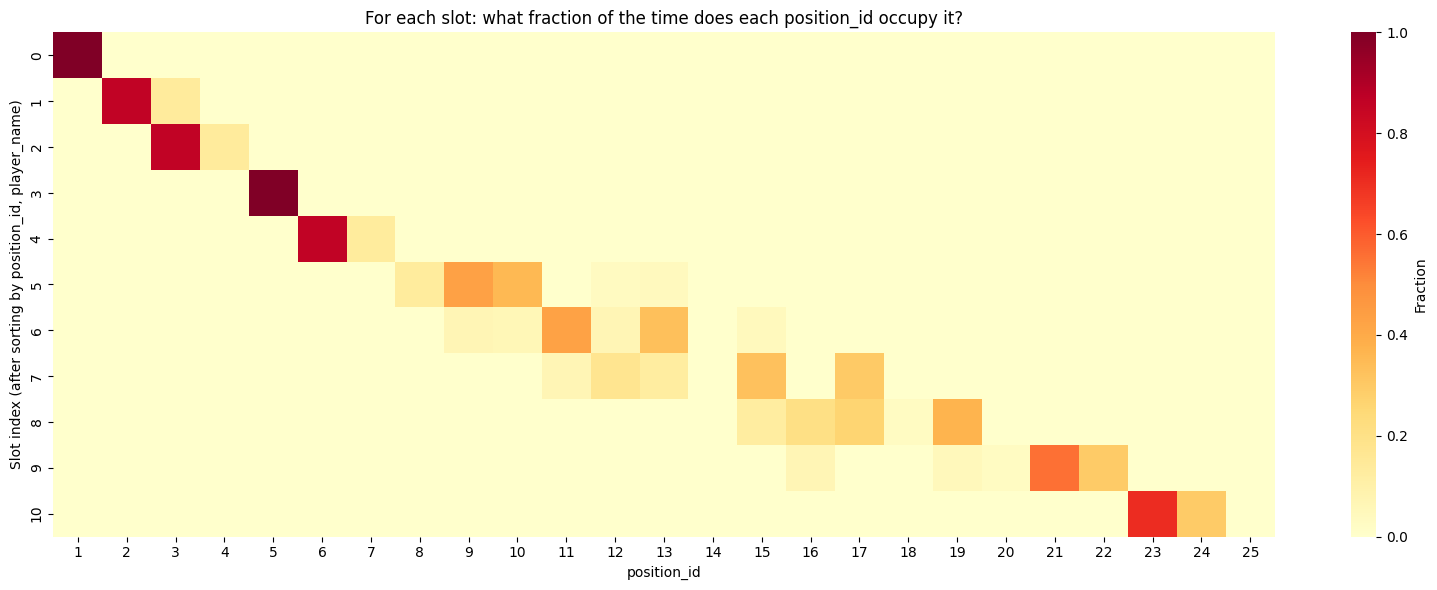

In [11]:
# For each (match, team), sort by (position_id, player_name) and assign slot indices 0..N-1
# Then check: for slot K, what is the distribution of position_id values?

slot_records = []
for (mid, team), group in df.groupby(["match_id", "team_name"]):
    sorted_group = group.sort_values(["position_id", "player_name"])
    for slot_idx, (_, row) in enumerate(sorted_group.iterrows()):
        slot_records.append({"slot": slot_idx, "position_id": int(row["position_id"]), 
                           "position_name": row["position_name"]})

slot_df = pd.DataFrame(slot_records)

# Only look at slots 0-10 (starting 11)
slot_df_11 = slot_df[slot_df["slot"] < 11]

# Heatmap: slot vs position_id frequency
pivot = slot_df_11.groupby(["slot", "position_id"]).size().unstack(fill_value=0)
# Normalize rows (each slot sums to 1)
pivot_norm = pivot.div(pivot.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(pivot_norm, annot=False, cmap="YlOrRd", ax=ax, cbar_kws={"label": "Fraction"})
ax.set_xlabel("position_id")
ax.set_ylabel("Slot index (after sorting by position_id, player_name)")
ax.set_title("For each slot: what fraction of the time does each position_id occupy it?")
plt.tight_layout()
plt.show()

In [ ]:
# Entropy of position_id distribution per slot (lower = more stable)
from scipy.stats import entropy

slot_entropy = pivot_norm.apply(lambda row: entropy(row[row > 0]), axis=1)

fig, ax = plt.subplots(figsize=(8, 4))
slot_entropy.plot(kind="bar", ax=ax, color="steelblue", edgecolor="black")
ax.set_xlabel("Slot index")
ax.set_ylabel("Entropy (bits)")
ax.set_title("Positional entropy per slot (lower = more consistent position assignment)")
plt.tight_layout()
plt.show()

print("Entropy per slot (lower = better for gMLP):")
for slot, ent in slot_entropy.items():
    # Most common position for this slot
    top_pos = pivot_norm.loc[slot].idxmax()
    top_frac = pivot_norm.loc[slot].max()
    print(f"  Slot {slot:2d}: entropy={ent:.3f}, most common pos_id={top_pos} ({100*top_frac:.1f}%)")

## 9. Alternative: coarse position groups

StatsBomb has 25 fine-grained positions. What if we group them into coarse roles (GK, DEF, MID, FWD) and sort by coarse group first, then by position_id within group?

In [ ]:
# Coarse position grouping based on StatsBomb position_id ranges
COARSE_GROUP = {
    1: "GK",       # Goalkeeper
    2: "DEF", 3: "DEF", 4: "DEF", 5: "DEF", 6: "DEF",    # Backs / CBs
    7: "DEF", 8: "DEF",                                      # Wing Backs
    9: "MID", 10: "MID", 11: "MID",                          # Defensive Mid
    12: "MID", 13: "MID", 14: "MID", 15: "MID", 16: "MID",  # Midfield
    17: "FWD", 18: "FWD", 19: "FWD", 20: "FWD", 21: "FWD",  # Attacking Mid / Wings
    22: "FWD", 23: "FWD", 24: "FWD", 25: "FWD",              # Forwards
}
COARSE_ORDER = {"GK": 0, "DEF": 1, "MID": 2, "FWD": 3}

df["coarse_group"] = df["position_id"].map(COARSE_GROUP)
df["coarse_order"] = df["coarse_group"].map(COARSE_ORDER)

# Distribution of coarse groups per team per match
coarse_comp = df.groupby(["match_id", "team_name"])["coarse_group"].value_counts().unstack(fill_value=0)
print("Coarse group counts per team per match:")
print(coarse_comp.describe())
print(f"\nMost common (GK, DEF, MID, FWD) compositions:")
coarse_comp_tuples = coarse_comp.apply(lambda row: (row.get("GK",0), row.get("DEF",0), row.get("MID",0), row.get("FWD",0)), axis=1)
print(coarse_comp_tuples.value_counts().head(15))

## 10. Slot stability with coarse-first ordering

Sort by (coarse_order, position_id, player_name) — does this improve slot consistency?

In [ ]:
# Recompute slot assignments with coarse-first ordering
slot_records_v2 = []
for (mid, team), group in df.groupby(["match_id", "team_name"]):
    sorted_group = group.sort_values(["coarse_order", "position_id", "player_name"])
    for slot_idx, (_, row) in enumerate(sorted_group.iterrows()):
        slot_records_v2.append({
            "slot": slot_idx, 
            "position_id": int(row["position_id"]),
            "coarse_group": row["coarse_group"],
        })

slot_df_v2 = pd.DataFrame(slot_records_v2)
slot_df_v2_11 = slot_df_v2[slot_df_v2["slot"] < 11]

# Heatmap: slot vs coarse group
pivot_coarse = slot_df_v2_11.groupby(["slot", "coarse_group"]).size().unstack(fill_value=0)
pivot_coarse = pivot_coarse[["GK", "DEF", "MID", "FWD"]]
pivot_coarse_norm = pivot_coarse.div(pivot_coarse.sum(axis=1), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

sns.heatmap(pivot_coarse_norm, annot=True, fmt=".2f", cmap="YlOrRd", ax=axes[0], cbar_kws={"label": "Fraction"})
axes[0].set_title("Coarse group distribution per slot\n(sorted by coarse_order → position_id → player_name)")
axes[0].set_xlabel("Coarse group")
axes[0].set_ylabel("Slot index")

# Fine-grained heatmap
pivot_v2 = slot_df_v2_11.groupby(["slot", "position_id"]).size().unstack(fill_value=0)
pivot_v2_norm = pivot_v2.div(pivot_v2.sum(axis=1), axis=0)
sns.heatmap(pivot_v2_norm, annot=False, cmap="YlOrRd", ax=axes[1], cbar_kws={"label": "Fraction"})
axes[1].set_title("Fine position_id distribution per slot\n(sorted by coarse_order → position_id → player_name)")
axes[1].set_xlabel("position_id")
axes[1].set_ylabel("Slot index")

plt.tight_layout()
plt.show()

In [ ]:
# Compare entropy: original ordering (just position_id) vs coarse-first ordering
slot_entropy_v2 = pivot_v2_norm.apply(lambda row: entropy(row[row > 0]), axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(11)
width = 0.35
ax.bar(x - width/2, slot_entropy.values[:11], width, label="Sort by position_id only", color="steelblue", edgecolor="black")
ax.bar(x + width/2, slot_entropy_v2.values[:11], width, label="Sort by coarse → position_id", color="coral", edgecolor="black")
ax.set_xlabel("Slot index")
ax.set_ylabel("Entropy")
ax.set_title("Slot stability: entropy of position_id per slot (lower = better)")
ax.legend()
ax.set_xticks(x)
plt.tight_layout()
plt.show()

print("Note: both orderings are equivalent since position_id already encodes the coarse ordering (1=GK, 2-8=DEF, 9-16=MID, 17-25=FWD)")

## 11. Match-level view: full sequence (team A + team B, sorted)

For gMLP the full sequence is `[team_A_slot_0, ..., team_A_slot_N, team_B_slot_0, ..., team_B_slot_M]`. Let's see the full picture.

In [ ]:
# Build full match sequences with canonical ordering
# Team A (alphabetically first) slots 0..N, then Team B slots N+1..N+M

match_slot_records = []
for mid, match_group in df.groupby("match_id"):
    teams = sorted(match_group["team_name"].unique())
    if len(teams) != 2:
        continue
    global_slot = 0
    for team in teams:
        team_group = match_group[match_group["team_name"] == team].sort_values(["position_id", "player_name"])
        for _, row in team_group.iterrows():
            match_slot_records.append({
                "match_id": mid,
                "global_slot": global_slot,
                "position_id": int(row["position_id"]),
                "coarse_group": COARSE_GROUP.get(int(row["position_id"]), "?"),
                "team": team,
            })
            global_slot += 1

match_slot_df = pd.DataFrame(match_slot_records)

# Heatmap for global slots (max_seq_length perspective)
max_slot = 36  # as in config
match_slot_36 = match_slot_df[match_slot_df["global_slot"] < max_slot]

pivot_global = match_slot_36.groupby(["global_slot", "position_id"]).size().unstack(fill_value=0)
pivot_global_norm = pivot_global.div(pivot_global.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(18, 10))
sns.heatmap(pivot_global_norm, annot=False, cmap="YlOrRd", ax=ax, cbar_kws={"label": "Fraction"})
ax.set_xlabel("position_id")
ax.set_ylabel("Global slot index (0-17: team A, 18-35: team B)")
ax.set_title("Full match sequence: position_id distribution per global slot\n(both teams, sorted by position_id within each team)")
ax.axhline(y=11, color="blue", linewidth=2, linestyle="--", label="Approx team boundary (11)")
ax.axhline(y=18, color="red", linewidth=2, linestyle="--", label="Max team A boundary (18)")
ax.legend()
plt.tight_layout()
plt.show()

## 12. Summary & Conclusions

In [ ]:
# Final quantitative summary
print("=" * 70)
print("SUMMARY: Feasibility of canonical ordering for gMLP")
print("=" * 70)

print(f"\n1. PLAYERS PER TEAM: varies from {int(team_match_counts['n_players'].min())} to {int(team_match_counts['n_players'].max())}")
print(f"   → Variable sequence length is a problem for gMLP's fixed W matrix")
print(f"   → Need padding to max_seq_length={36}")

print(f"\n2. POSITION DUPLICATES:")
pct_no_dupes = 100 * (ambig['n_ambiguous'] == 0).mean()
print(f"   → {pct_no_dupes:.1f}% of teams have NO duplicate positions (fully unique ordering)")
print(f"   → Mean ambiguous players per team: {ambig['n_ambiguous'].mean():.1f}")

print(f"\n3. UNIQUE COMPOSITIONS:")
print(f"   → All teams: {compositions['composition'].nunique()} unique compositions")
if len(comp_11) > 0:
    print(f"   → 11-player teams only: {comp_11['composition'].nunique()} unique compositions")

print(f"\n4. SLOT STABILITY (entropy, first 11 slots):")
print(f"   → Slot 0: entropy={slot_entropy.values[0]:.3f} (should be ~0 if always GK)")
print(f"   → Mean entropy slots 0-10: {slot_entropy.values[:11].mean():.3f}")
print(f"   → Max entropy (worst slot): {slot_entropy.values[:11].max():.3f}")

print(f"\n5. CONCLUSION:")
print(f"   Sorting by position_id gives a REASONABLE canonical ordering.")
print(f"   Slot 0 = GK (very stable), slots 1-4 = defenders (fairly stable),")
print(f"   middle slots are noisier due to varied formations.")
print(f"   The ordering is imperfect but usable as an MLP baseline.")
print(f"   Key limitation: W learns 'slot-to-slot' not 'role-to-role' interactions.")